# 🧠🤖 Classificadores MLP - Identificação de Diabetes

Classificador de diabetes baseado em informação. Dataset: `alexteboul/diabetes-health-indicators-dataset`

In [1]:
import kagglehub
import numpy as np
import torch
import torch.nn as nn
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

ds_path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
ds_path

/home/Heitor-Guerra/IdeaProjects/Redes_Neurais/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/Heitor-Guerra/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1'

---------------------------
# Hiperparâmetros

Espaço com hiperparâmetros que podem ser alterados

In [12]:
# DataLoader
batch_size = 64
shuffle = True

# Otimizador
learning_rate = 1e-4

# Treino
n_epochs = 50

# Rede Neural
n_ins = 21
n_classes = 3
classes = ["Sem_diabetes", "Prediabetes", "Diabetes"]
n_hidden_neurons = 128
n_hidden_layers = 3
act_fn = nn.ReLU()

--------------------
# Leitura dos Dados

Espaço para leitura dos dados no arquivo csv

In [13]:
import pandas as pd
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def read_data(path):
    df = pd.read_csv(path)
    labels = df["Diabetes_012"].values
    data = df.iloc[:, 1:].values
    return data, labels

train_data = read_data(os.path.join(ds_path, "diabetes_012_health_indicators_BRFSS2015.csv"))
test_data = read_data(os.path.join(ds_path, "diabetes_012_test_health.csv"))

train_data

cuda


(array([[ 1.,  1.,  1., ...,  9.,  4.,  3.],
        [ 0.,  0.,  0., ...,  7.,  6.,  1.],
        [ 1.,  1.,  1., ...,  9.,  4.,  8.],
        ...,
        [ 1.,  1.,  1., ...,  9.,  2.,  1.],
        [ 0.,  1.,  1., ..., 10.,  6.,  8.],
        [ 0.,  0.,  1., ...,  7.,  6.,  8.]], shape=(220060, 21)),
 array([0., 0., 0., ..., 2., 0., 0.], shape=(220060,)))

--------------------
# Criação do Dataset

Preparação de dataset custom para armazenar os dados

In [14]:
from torch.utils.data import Dataset

class DiabetesDataset(Dataset):
  def __init__(self, x, y):
    self._x = x
    self._y = y

  def __len__(self):
      return len(self._y)

  def __getitem__(self, i):
      x = self._x[i]
      y = self._y[i]
      x = torch.tensor(x, dtype=torch.float32)
      y = torch.tensor(y, dtype=torch.long)

      return x, y

train_ds = DiabetesDataset(train_data[0], train_data[1])
test_ds = DiabetesDataset(test_data[0], test_data[1])

-----------------
# Criação do DataLoader

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=shuffle)

------------
# Criação da Rede Neural

In [16]:
net = nn.Sequential(
    nn.Linear(n_ins, n_hidden_neurons),
    act_fn
)

for i in range(n_hidden_layers):
    net.append(nn.Linear(n_hidden_neurons, n_hidden_neurons))
    net.append(act_fn)
net.append(nn.Linear(n_hidden_neurons, n_classes))

if device.type == "cuda":
    net = nn.DataParallel(net).to("cuda")

net

DataParallel(
  (module): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)

Criação da Loss Function

In [17]:
from sklearn.utils.class_weight import compute_class_weight

_classes = np.array([0,1,2])

weights = compute_class_weight("balanced", classes=_classes, y=train_data[1])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Criação do otimizador

In [18]:
import torch.optim as optim

optimizer = optim.Adam(net.parameters(), learning_rate)

-----------------
# Loops de treino e avaliação

- Loop de treino

In [19]:
def train(loader, net):
    all_preds = []
    all_labels = []

    for batch in loader:
        data, labels = batch
        data = data.to("cuda")
        labels_cuda = labels.to("cuda")

        optimizer.zero_grad()

        outputs = net(data)

        loss = criterion(outputs, labels_cuda)
        loss.backward()

        optimizer.step()

        outputs = outputs.cpu()
        pred = np.argmax(outputs.detach().numpy(), axis=-1)

        all_preds.extend(list(pred))
        all_labels.extend(labels.numpy())

    return all_labels, all_preds

- Loop de avaliação

In [20]:
def eval_loop(loader, net):
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            data, labels = batch
            data = data.to("cuda")

            outputs = net(data)

            outputs = outputs.cpu()
            preds = np.argmax(outputs.detach().numpy(), axis=-1)

            all_preds.extend(list(preds))
            all_labels.extend(labels)
    return all_labels, all_preds

--------
# Main Function

In [21]:
from sklearn.metrics import accuracy_score

history = []

for i in range(n_epochs):
    true, pred = train(train_loader, net)
    train_acc = accuracy_score(true, pred)

    true, pred = eval_loop(test_loader, net)
    test_acc = accuracy_score(true, pred)

    history.append((train_acc, test_acc))
    print(f"Epoch {i}: Train acc={train_acc:.2f}, Test acc={test_acc:.2f}")

Epoch 0: Train acc=0.66, Test acc=0.72
Epoch 1: Train acc=0.68, Test acc=0.71
Epoch 2: Train acc=0.69, Test acc=0.65
Epoch 3: Train acc=0.69, Test acc=0.69
Epoch 4: Train acc=0.69, Test acc=0.64
Epoch 5: Train acc=0.69, Test acc=0.65
Epoch 6: Train acc=0.69, Test acc=0.67
Epoch 7: Train acc=0.69, Test acc=0.71
Epoch 8: Train acc=0.69, Test acc=0.67
Epoch 9: Train acc=0.69, Test acc=0.68
Epoch 10: Train acc=0.69, Test acc=0.62
Epoch 11: Train acc=0.69, Test acc=0.72
Epoch 12: Train acc=0.69, Test acc=0.62
Epoch 13: Train acc=0.69, Test acc=0.69
Epoch 14: Train acc=0.68, Test acc=0.69
Epoch 15: Train acc=0.68, Test acc=0.68
Epoch 16: Train acc=0.69, Test acc=0.68
Epoch 17: Train acc=0.68, Test acc=0.66
Epoch 18: Train acc=0.68, Test acc=0.68
Epoch 19: Train acc=0.68, Test acc=0.67
Epoch 20: Train acc=0.68, Test acc=0.72
Epoch 21: Train acc=0.68, Test acc=0.71
Epoch 22: Train acc=0.68, Test acc=0.68
Epoch 23: Train acc=0.68, Test acc=0.68
Epoch 24: Train acc=0.68, Test acc=0.70
Epoch 25: 

Gráfico de Evolução da acurácia

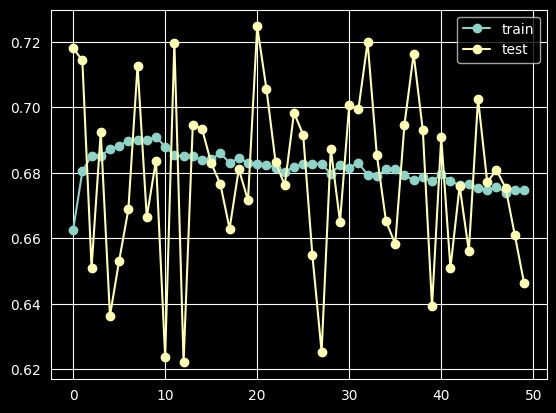

In [22]:
import matplotlib.pyplot as plt
history = np.array(history)
plt.plot(history[:,0], "-o")
plt.plot(history[:,1], "-o")
plt.legend(["train", "test"])

Relatório de classificação

In [23]:
from sklearn.metrics import classification_report

true, pred = eval_loop(test_loader, net)
print(classification_report(true, pred))

              precision    recall  f1-score   support

           0       0.96      0.63      0.76     28383
           1       0.03      0.13      0.05       587
           2       0.30      0.78      0.44      4650

    accuracy                           0.65     33620
   macro avg       0.43      0.52      0.41     33620
weighted avg       0.85      0.65      0.71     33620

